Models:
- Logistic Regression
- Tree Decision
- Random Forest
- CatBoost
- XGBoost
- Light GBM

For imbalance fix:
- `class-weight`
- `undersampling` & `oversampling`
- `SMOTE`

In [63]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
import optuna
import shap

from sklearn.metrics import (precision_score,
                             recall_score,
                             average_precision_score,
                             f1_score,
                             brier_score_loss,
                             classification_report,
                             confusion_matrix,
                             precision_recall_curve)

import joblib

In [2]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

## New Features

In [3]:
df['log_amount'] = np.log1p(df['amount'])
df['day'] = (df['step'] - 1) // 24
df['hour'] = (df['step'] - 1) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['step', 'type',
            'amount', 'log_amount',
            'day', 'hour_sin',
            'hour_cos']

target = ['isFraud']

df = df[features + target]

df['type'] = df['type'].astype('category')

In [4]:
test_point = 550
threshold_point = 500
calibration_point = 450
validation_point = 400

test = df[df['step'] > test_point].copy()
threshold = df[(df['step'] <= test_point) & (df['step'] > threshold_point)].copy()
calibration = df[(df['step'] <= threshold_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()
train = df[df['step'] <= validation_point].copy()

In [5]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_threshold, y_threshold = threshold.drop('isFraud', axis=1), threshold['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

In [6]:
categorial_features = ['type']
numeric_features = ['amount', 'log_amount']
other_features =['step', 'day', 'hour_sin', 'hour_cos']

## Pipelines

### Logistic Regression

#### Logistic Regression Preprocessing

In [7]:
log_reg_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Logistic Regression Pipelines

In [8]:
log_reg_models = {
    'base': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED)
        )
    ]),

    'balanced': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ])
}

### Decision Tree Classifier

#### Decision Tree Preprocessor

In [9]:
dt_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Decision Tree Pipelines

In [10]:
df_models = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight=None,
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ])
}

### Random Forest

#### Random Forest Preprocessor

In [11]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Random Forest Pipelines

In [12]:
rf_models = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight=None,
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ])
}

### XGBoost

#### XGBoost Pipelines

In [13]:
xgb_models = {

    'base': XGBClassifier(
        enable_categorical=True,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
}

### Catboost

#### Catboost Pipelines

In [14]:
cb_models = {
    'base': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        thread_count=4,
        used_ram_limit='6gb',

        random_seed=RANDOM_SEED,
        verbose=False
    ),

    'balanced': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        auto_class_weights='Balanced',

        thread_count=4,
        used_ram_limit='6gb',

        random_seed=RANDOM_SEED,
        verbose=False
    )
}

### Light Gradient Boosting

#### LGBM Pipelines

In [15]:
lgbm_models = {

    # base
    'base': LGBMClassifier(
        objective='binary',
        class_weight=None,
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=8,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=-1,
        random_state=RANDOM_SEED
    ),

    # balanced
    'balanced': LGBMClassifier(
        class_weight='balanced',
        objective='binary',
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=8,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=-1,
        random_state=RANDOM_SEED
    )
}

### Results

In [16]:
sampling_strategies = {
    'base': None,

    'under.05': RandomUnderSampler(
        sampling_strategy=0.05,
        random_state=RANDOM_SEED
    ),

    'under.10': RandomUnderSampler(
        sampling_strategy=0.10,
        random_state=RANDOM_SEED
    ),

    'under.20': RandomUnderSampler(
        sampling_strategy=0.20,
        random_state=RANDOM_SEED
    ),

    'over.005': RandomOverSampler(
        sampling_strategy=0.005,
        random_state=RANDOM_SEED
    ),

    'over.01': RandomOverSampler(
        sampling_strategy=0.01,
        random_state=RANDOM_SEED
    ),

    'over.02': RandomOverSampler(
        sampling_strategy=0.02,
        random_state=RANDOM_SEED
    ),

    'smote.01': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.01,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),

    'smote.02': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.02,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),
}

In [17]:
models_dict = {
    'Logistic Regression': log_reg_models,
    'Decision Tree': df_models,
    'Random Forest': rf_models,
    'XGBoost': xgb_models,
    'Catboost': cb_models,
    'LGBM': lgbm_models
}

In [18]:
def apply_sampling(X, y, sampler):
    if sampler is None:
        return X.copy(), y.copy()

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    X_resampled['type'] = X_resampled['type'].astype('category')

    return X_resampled, y_resampled

In [19]:
def model_estimation(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    average_precision = average_precision_score(y_true, y_proba)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'average_precision': average_precision,
    }

In [20]:
def evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        sampler_name=None,
        sampler=None,
        fit_params=None
):
    X_sampled, y_sampled = apply_sampling(
        X_train,
        y_train,
        sampler
    )

    start = time.time()

    if fit_params is None:
        fit_params = {}

    model.fit(
        X_sampled,
        y_sampled,
        **fit_params
    )

    training_time = time.time() - start

    y_proba = model.predict_proba(X_val)[:, 1]

    metrics = model_estimation(
        y_val,
        y_proba
    )

    metrics['model'] = model_name
    metrics['sampling'] = sampler_name
    metrics['fit_time'] = round(training_time, 0)

    return model, metrics

In [21]:
res_val_table = pd.DataFrame(
    columns=[
        'model',
        'sampling',
        'precision',
        'recall',
        'f1',
        'average_precision',
        'fit_time'
    ]
)

**Code bellow commented because it works about hour**

In [22]:
folds = [
    (250, 300),
    (300, 350),
    (350, 400),
    (400, 450),
]

In [23]:
results = []

for model_name, model_configs in models_dict.items():
    print(model_name)

    # CV
    for fold_idx, (train_end, val_end) in enumerate(folds, start=1):
        print(f"  Fold {fold_idx}/{len(folds)}")


        # Temporal split
        train_fold = df[
            df["step"] <= train_end
        ].copy()

        val_fold = df[
            (df["step"] > train_end)
            & (df["step"] <= val_end)
        ].copy()

        X_train_fold = train_fold.drop("isFraud", axis=1)
        y_train_fold = train_fold["isFraud"]

        X_val_fold = val_fold.drop("isFraud", axis=1)
        y_val_fold = val_fold["isFraud"]


        # Fold-specific fit params
        if model_name == "Catboost":
            fit_params = {
                "cat_features": ["type"],
                "eval_set": (X_val_fold, y_val_fold),
                "early_stopping_rounds": 50,
                "verbose": False,
            }

        elif model_name == "LGBM":
            fit_params = {
                "categorical_feature": ["type"],
                "eval_X": X_val_fold,
                "eval_y": y_val_fold,
                "eval_metric": "average_precision",
                "callbacks": [
                    lgb.early_stopping(50, verbose=False)
                ],
            }

        else:
            fit_params = None

        # Model configurations
        for config_name, model_config in model_configs.items():

            # via class_weight / auto_class_weights
            if config_name == "balanced":
                print(f"    {config_name}")

                fitted_model, metrics = evaluate_model(
                    model_name=model_name,
                    model=clone(model_config),
                    X_train=X_train_fold,
                    y_train=y_train_fold,
                    X_val=X_val_fold,
                    y_val=y_val_fold,
                    sampler_name="balanced",
                    sampler=None,
                    fit_params=fit_params,
                )

                metrics.update({
                    "fold": fold_idx,
                    "train_end": train_end,
                    "val_end": val_end,
                    "config": config_name,
                })

                results.append(metrics)

            # base model + different sampling strategies
            else:
                for sampling_name, sampling_strategy in sampling_strategies.items():
                    print(f"    {config_name} | {sampling_name}")

                    fitted_model, metrics = evaluate_model(
                        model_name=model_name,
                        model=clone(model_config),
                        X_train=X_train_fold,
                        y_train=y_train_fold,
                        X_val=X_val_fold,
                        y_val=y_val_fold,
                        sampler_name=sampling_name,
                        sampler=sampling_strategy,
                        fit_params=fit_params,
                    )

                    metrics.update({
                        "fold": fold_idx,
                        "train_end": train_end,
                        "val_end": val_end,
                        "config": config_name,
                    })

                    results.append(metrics)

    print()


res_val_table = pd.DataFrame(results)

In [24]:
# cv_results = (
#     res_val_table
#     .groupby(
#         ["model", "config", "sampling"],
#         as_index=False
#     )
#     .agg(
#         mean_ap=("average_precision", "mean"),
#         std_ap=("average_precision", "std"),
#         mean_precision=("precision", "mean"),
#         mean_recall=("recall", "mean"),
#         mean_f1=("f1", "mean"),
#         mean_fit_time=("fit_time", "mean"),
#     )
#     .sort_values(
#         by="mean_ap",
#         ascending=False
#     )
# )
#
# cv_results.head(15)

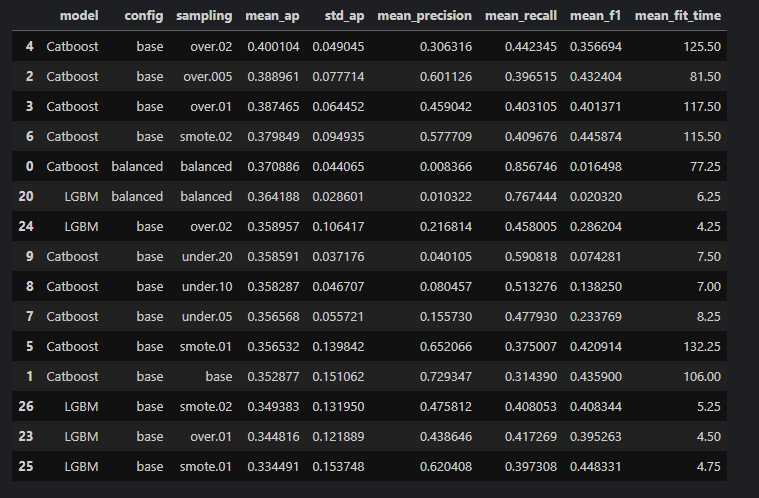

CatBoost provided strong ranking performance, but LightGBM achieved higher Average Precision while training substantially faster.

### Models selected for hyperparameter tuning

Based on validation Average Precision from the initial model comparison,
LightGBM and CatBoost were selected for further hyperparameter tuning.

XGBoost was not included in the tuning stage because its baseline
performance was lower than the two leading boosting models, while
requiring additional computational resources

## Hyperparameter Tuning

### Catboost tuning

In [25]:
def objective_catboost(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),

        'depth': trial.suggest_int('depth', 4, 8),

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15,log=True),

        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1, 20, log=True),

        'random_strength': trial.suggest_float(
            'random_strength', 0.01, 5, log=True),

        'bagging_temperature': trial.suggest_float(
            'bagging_temperature', 0, 2),

        'auto_class_weights': None,

        'loss_function': 'Logloss',

        'random_seed': RANDOM_SEED,
        'verbose': False
    }

    X_sampled, y_sampled = apply_sampling(
        X_train,
        y_train,
        sampler=RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED
        )
    )


    model = CatBoostClassifier(**params)

    model.fit(
        X_sampled,
        y_sampled,

        cat_features=['type'],
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        verbose=False
    )

    y_proba = model.predict_proba(X_val)[:, 1]

    return average_precision_score(
        y_val,
        y_proba
    )

study_catboost = optuna.create_study(
    direction='maximize',
)


study_catboost.optimize(
    objective_catboost,
    n_trials=20
)

[I 2026-08-20 12:31:16,123] A new study created in memory with name: no-name-e0aa4da0-b413-4b3e-96ac-8f832ec6ecf3
[I 2026-08-20 12:36:01,592] Trial 0 finished with value: 0.2955235720794657 and parameters: {'iterations': 215, 'depth': 4, 'learning_rate': 0.047900949876428296, 'l2_leaf_reg': 2.5735272231166917, 'random_strength': 3.4038641112018326, 'bagging_temperature': 0.7770183610634074}. Best is trial 0 with value: 0.2955235720794657.
[I 2026-08-20 12:48:28,577] Trial 1 finished with value: 0.3491228283707216 and parameters: {'iterations': 529, 'depth': 7, 'learning_rate': 0.017744841730056065, 'l2_leaf_reg': 8.855325890512258, 'random_strength': 0.21560570070209004, 'bagging_temperature': 0.8979726584507444}. Best is trial 1 with value: 0.3491228283707216.
[I 2026-08-20 12:57:10,294] Trial 2 finished with value: 0.26021477114546243 and parameters: {'iterations': 596, 'depth': 4, 'learning_rate': 0.013532602438155888, 'l2_leaf_reg': 1.5687902040271735, 'random_strength': 2.04482681

In [26]:
catboost_model = ImbPipeline(steps=[
        ('sampler', RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            **study_catboost.best_params,
            random_state=RANDOM_SEED,
            verbose=False,
            auto_class_weights=None)
         )
    ])

['../models/catboost_model_optimized.joblib']

### LightGBM tuning

In [27]:
def objective_lgbm(trial):

    params = {
        'objective': 'binary',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),

        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.15, log=True),

        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 4, 12),

        'min_child_samples': trial.suggest_int(
            'min_child_samples', 20, 200),

        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0),

        'subsample_freq': 1,

        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-8, 10.0, log=True),

        'reg_lambda': trial.suggest_float(
            'reg_lambda', 1e-8, 10.0, log=True),

        'class_weight': 'balanced',

        'n_jobs': 4,
        'random_state': RANDOM_SEED,
        'verbosity': -1
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train,
        y_train,
        categorical_feature=['type'],
        eval_X=X_val,
        eval_y=y_val,
        eval_metric='average_precision',
        callbacks=[
            lgb.early_stopping(50, verbose=False)
        ]
    )

    y_proba = model.predict_proba(X_val)[:, 1]

    return average_precision_score(
        y_val,
        y_proba
    )


study_lgbm = optuna.create_study(
    direction='maximize'
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=30
)

[I 2026-08-20 14:57:53,005] A new study created in memory with name: no-name-e85106cb-b033-426c-aa8a-470992854368
[I 2026-08-20 14:58:26,665] Trial 0 finished with value: 0.10421896666973646 and parameters: {'n_estimators': 705, 'learning_rate': 0.026979686849138793, 'num_leaves': 43, 'max_depth': 12, 'min_child_samples': 114, 'subsample': 0.9915190664142387, 'reg_alpha': 0.09269792440356064, 'reg_lambda': 8.527701252807387e-06}. Best is trial 0 with value: 0.10421896666973646.
[I 2026-08-20 14:58:43,141] Trial 1 finished with value: 0.3215723769305863 and parameters: {'n_estimators': 593, 'learning_rate': 0.03935429935932534, 'num_leaves': 58, 'max_depth': 4, 'min_child_samples': 188, 'subsample': 0.7438956961681852, 'reg_alpha': 1.2675164513621252e-06, 'reg_lambda': 2.015246212243919e-08}. Best is trial 1 with value: 0.3215723769305863.
[I 2026-08-20 14:58:57,297] Trial 2 finished with value: 0.1015084304823739 and parameters: {'n_estimators': 407, 'learning_rate': 0.0188067939118212

In [28]:
lgbm_model = LGBMClassifier(**study_lgbm.best_params)

lgbm_model.set_params(
    n_jobs=-1,
    verbosity=-1,
    random_state=RANDOM_SEED,
    class_weight='balanced',
    objective='binary'
)

['../models/lgbm_model_optimized.joblib']

### Best models estimation

In [30]:
top_models = {
    'catboost': catboost_model,
    'lgbm': lgbm_model
}

In [31]:
results = []

for model_name, model_config in top_models.items():
    print(model_name)

    # CV
    for fold_idx, (train_end, val_end) in enumerate(folds, start=1):
        print(f" Fold {fold_idx}/{len(folds)}")


        # Temporal split
        train_fold = df[
            df["step"] <= train_end
        ].copy()

        val_fold = df[
            (df["step"] > train_end)
            & (df["step"] <= val_end)
        ].copy()

        X_train_fold = train_fold.drop("isFraud", axis=1)
        y_train_fold = train_fold["isFraud"]

        X_val_fold = val_fold.drop("isFraud", axis=1)
        y_val_fold = val_fold["isFraud"]


        if model_name == "catboost":
            model_config = catboost_model.named_steps['classifier']
            sampler_name = 'OverSampler_0.02'
            sampler = catboost_model.named_steps['sampler']
            fit_params = {
                "cat_features": ["type"],
                "eval_set": (X_val_fold, y_val_fold),
                "early_stopping_rounds": 50,
                "verbose": False,
            }

        elif model_name == "lgbm":
            sampler = None
            sampler_name = None
            fit_params = {
                "categorical_feature": ["type"],
                "eval_X": X_val_fold,
                "eval_y": y_val_fold,
                "eval_metric": "average_precision",
                "callbacks": [
                    lgb.early_stopping(50, verbose=False)
                ]
            }


        fitted_model, metrics = evaluate_model(
            model_name=model_name,
            model=clone(model_config),
            X_train=X_train_fold,
            y_train=y_train_fold,
            X_val=X_val_fold,
            y_val=y_val_fold,
            sampler_name=sampler_name,
            sampler=sampler,
            fit_params=fit_params,
        )

        metrics.update({
            "fold": fold_idx,
            "train_end": train_end,
            "val_end": val_end,
            "config": model_name,
        })

        results.append(metrics)

    print()


res_val_table = pd.DataFrame(results)

catboost
 Fold 1/4
 Fold 2/4
 Fold 3/4
 Fold 4/4

lgbm
 Fold 1/4
 Fold 2/4
 Fold 3/4
 Fold 4/4



In [33]:
res_val_table

,precision,recall,f1,average_precision,model,sampling,fit_time,fold,train_end,val_end,config
0,0.302168,0.398214,0.343606,0.387139,catboost,balanced,396.0,1,250,300,catboost
1,0.413333,0.434000,0.423415,0.431518,catboost,balanced,581.0,2,300,350,catboost
2,0.400000,0.465278,0.430177,0.452880,catboost,balanced,858.0,3,350,400,catboost
3,0.203947,0.481034,0.286448,0.355226,catboost,balanced,596.0,4,400,450,catboost
4,0.008398,0.673214,0.016590,0.354017,lgbm,balanced,59.0,1,250,300,lgbm
5,0.005476,0.770000,0.010874,0.373529,lgbm,balanced,25.0,2,300,350,lgbm
6,0.006170,0.803819,0.012246,0.425045,lgbm,balanced,31.0,3,350,400,lgbm
7,0.018514,0.855172,0.036243,0.382033,lgbm,balanced,13.0,4,400,450,lgbm


In [32]:
cv_results = (
    res_val_table
    .groupby(
        ["model", "config", "sampling"],
        as_index=False
    )
    .agg(
        mean_ap=("average_precision", "mean"),
        std_ap=("average_precision", "std"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        mean_fit_time=("fit_time", "mean"),
    )
    .sort_values(
        by="mean_ap",
        ascending=False
    )
)

cv_results

,model,config,sampling,mean_ap,std_ap,mean_precision,mean_recall,mean_f1,mean_fit_time
0,catboost,catboost,balanced,0.406691,0.043897,0.329862,0.444632,0.370911,607.75
1,lgbm,lgbm,balanced,0.383656,0.029982,0.009640,0.775552,0.018988,32.00


## Train the best model on train + val

In [96]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [101]:
catboost_model.named_steps['classifier'].set_params(cat_features=["type"])

In [102]:
catboost_model.fit(X_dev, y_dev)

,steps,"[('sampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](7,)","['step','type','amount',...,'day','hour_sin','hour_cos']"
n_features_in_,int,7
,sampling_strategy,0.02
,random_state,42
,shrinkage,None


## Calibration

In [104]:
calibrated_model_isotonic = CalibratedClassifierCV(
    estimator=FrozenEstimator(catboost_model),
    method='isotonic'
)

calibrated_model_sigmoid = CalibratedClassifierCV(
    estimator=FrozenEstimator(catboost_model),
    method='sigmoid'
)

calibrated_model_isotonic.fit(X_cal, y_cal)
calibrated_model_sigmoid.fit(X_cal, y_cal)

y_proba_raw = catboost_model.predict_proba(X_cal)[:, 1]
y_proba_isotonic = calibrated_model_isotonic.predict_proba(X_cal)[:, 1]
y_proba_sigmoid = calibrated_model_sigmoid.predict_proba(X_cal)[:, 1]

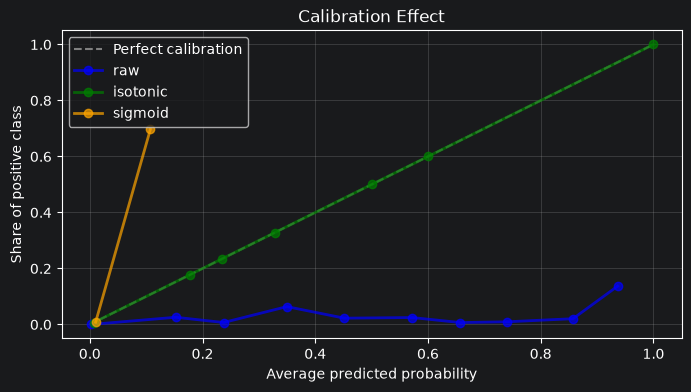

In [105]:
# Calibration graph

fop_orig_raw, mpv_orig_raw = calibration_curve(y_cal, y_proba_raw,
                                               n_bins=10)

fop_orig_isotonic, mpv_orig_isotonic = calibration_curve(y_cal, y_proba_isotonic,
                                                         n_bins=10)

fop_orig_sigmoid, mpv_orig_sigmoid = calibration_curve(y_cal, y_proba_sigmoid,
                                                       n_bins=10)

display_setup = ['blue', 'green', 'orange']

plt.figure(figsize=(8, 4))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(mpv_orig_raw, fop_orig_raw, marker='o', linewidth=2,
         label='raw', alpha=0.7, color=display_setup[0])
plt.plot(mpv_orig_isotonic, fop_orig_isotonic, marker='o', linewidth=2,
         label='isotonic', alpha=0.7, color=display_setup[1])
plt.plot(mpv_orig_sigmoid, fop_orig_sigmoid, marker='o', linewidth=2,
         label='sigmoid', alpha=0.7, color=display_setup[2])

plt.title('Calibration Effect')
plt.xlabel('Average predicted probability')
plt.ylabel('Share of positive class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [106]:
# Brier score
brier_raw = brier_score_loss(y_cal, y_proba_raw)
brier_isotonic = brier_score_loss(y_cal, y_proba_isotonic)
brier_sigmoid = brier_score_loss(y_cal, y_proba_sigmoid)

print(f"Brier score (raw): {brier_raw:.4f}")
print(f"Brier score (isotonic): {brier_isotonic:.4f}")
print(f"Brier score (sigmoid): {brier_sigmoid:.4f}")

Brier score (raw): 0.2083
Brier score (isotonic): 0.0078
Brier score (sigmoid): 0.0099


## Searching for a classification threshold

In [107]:
def threshold_searching(
    y_true,
    y_proba,
    beta=2
):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_proba
    )

    precision = precision[:-1]
    recall = recall[:-1]

    beta_sq = beta ** 2

    fbeta = (
        (1 + beta_sq)
        * precision
        * recall
        / (beta_sq * precision + recall + 1e-12)
    )

    best_idx = np.argmax(fbeta)

    best_threshold = thresholds[best_idx]

    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Precision: {precision[best_idx]:.4f}")
    print(f"Recall: {recall[best_idx]:.4f}")
    print(f"F_beta: {fbeta[best_idx]:.4f}")

    return best_threshold

In [108]:
y_proba_threshold = calibrated_model_isotonic.predict_proba(X_threshold)[:, 1]
best_threshold = threshold_searching(y_threshold, y_proba_threshold)
y_pred_threshold = (y_proba_threshold >= best_threshold).astype(int)

Best threshold: 0.0667
Precision: 0.3498
Recall: 0.3790
F_beta: 0.3728


In [109]:
print(f"Metrics with threshold {best_threshold:.4f}:")
print(f"Precision: {precision_score(y_threshold, y_pred_threshold):.3f}")
print(f"Recall: {recall_score(y_threshold, y_pred_threshold):.3f}")
print(f"F1: {f1_score(y_threshold, y_pred_threshold):.3f}")
print(f"PR: {average_precision_score(y_threshold, y_proba_threshold):.3f}\n")

print('Classification report:')
print(classification_report(y_threshold, y_pred_threshold))

Metrics with threshold 0.0667:
Precision: 0.350
Recall: 0.379
F1: 0.364
PR: 0.311

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    103708
           1       0.35      0.38      0.36       504

    accuracy                           0.99    104212
   macro avg       0.67      0.69      0.68    104212
weighted avg       0.99      0.99      0.99    104212



## Test set

In [110]:
y_proba_test = calibrated_model_isotonic.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

print(f"Metrics on the test set:")
print(f"Precision: {precision_score(y_test, y_pred_test):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.3f}")
print(f"F1: {f1_score(y_test, y_pred_test):.3f}")
print(f"PR: {average_precision_score(y_test, y_proba_test):.3f}\n")

print('Classification report:')
print(classification_report(y_test, y_pred_test))

Metrics on the test set:
Precision: 0.384
Recall: 0.379
F1: 0.382
PR: 0.345

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    194453
           1       0.38      0.38      0.38      2148

    accuracy                           0.99    196601
   macro avg       0.69      0.69      0.69    196601
weighted avg       0.99      0.99      0.99    196601



## Classification Matrix

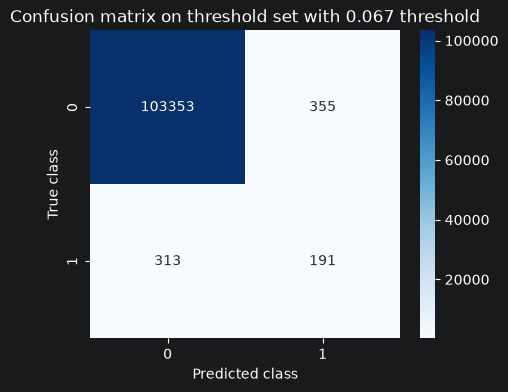

In [111]:
# Calibration set
cm = confusion_matrix(y_threshold, y_pred_threshold)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Confusion matrix on threshold set with {best_threshold:.3f} threshold')
plt.show()

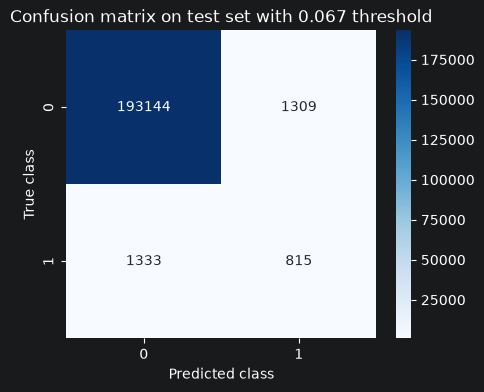

In [112]:
# Test set
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Confusion matrix on test set with {best_threshold:.3f} threshold')
plt.show()

## Feature importance

In [113]:
X_shap = X_dev.sample(
    n=10_000,
    random_state=RANDOM_SEED
)

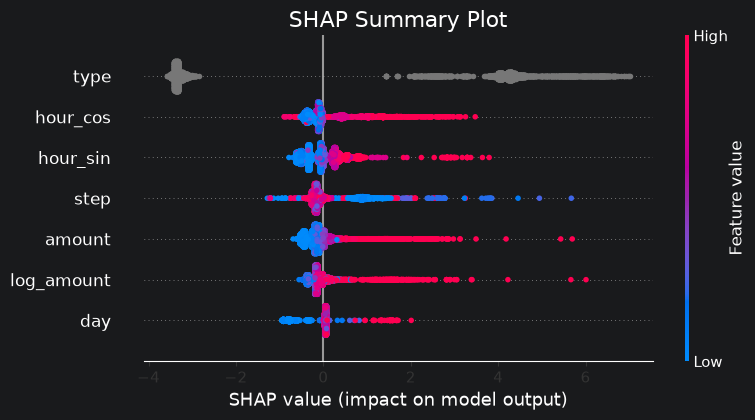

In [114]:
def shap_plot(model):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values,
                      X_shap,
                      feature_names=X_shap.columns,
                      show=False)
    ax = plt.gca()
    ax.set_yticklabels(ax.get_yticklabels(), color='white', fontsize=12)

    plt.title("SHAP Summary Plot", fontsize=16)
    plt.tight_layout()
    plt.show()

shap_plot(calibrated_model_isotonic.estimator.estimator.named_steps['classifier'])


## Final Model Saving

In [115]:
artifact = {
    "model": calibrated_model_isotonic,
    "threshold": best_threshold,
    "beta": 2,
    "features": features,
}

joblib.dump(
    artifact,
    "../models/catboost_fraud_model.joblib"
)

['../models/final_model.joblib']